In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import os
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
os.chdir(r"C:\Users\quinc\Downloads\archive")

# 1. DATA PREPARATION & SAMPLING (The "Niche" Dataset)
# Goal: < 1000 images per class [cite: 13]
selected_classes = ['Compact', 'Sedan', 'Off-Road/Pickup', 'Convertible', 'Coupe', 'Station Wagon']
df = pd.read_csv(r"fullGas.csv") # Ensure 'image_path' and 'bodytype' columns exist
filtered_df = df[df['Body'].isin(selected_classes)]

# Sample 500 images per class to ensure "niche" status [cite: 13]
niche_df = filtered_df.groupby('Body').apply(
    lambda x: x.sample(n=min(len(x), 500), random_state=42)
).reset_index(drop=True)

train_df, val_df = train_test_split(niche_df, test_size=0.2, stratify=niche_df['Body'])

C:\Users\quinc\AppData\Local\Temp\ipykernel_31692\3361787543.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  niche_df = filtered_df.groupby('Body').apply(


In [28]:

# 2. DATA AUGMENTATION [cite: 19, 20]
# Requirement: Rotation, Zoom, and Color Jitter (Brightness)
data_aug = tf.keras.Sequential([
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2) 
])

In [29]:

# 3. BASELINE MODEL: Simple CNN from Scratch [cite: 16, 17]
def build_baseline(num_classes):
    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        data_aug,
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.Flatten(), # Baseline uses Flatten [cite: 17, 46]
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [30]:
# 4. TRANSFER LEARNING MODEL: MobileNetV2 [cite: 22, 27, 30]
def build_transfer_model(num_classes):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3), include_top=False, weights='imagenet'
    )
    
    # Requirement: Freeze the backbone [cite: 30]
    base_model.trainable = False 
    
    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        data_aug,
        base_model,
        # Requirement: Use GAP instead of Flatten [cite: 27, 28]
        layers.GlobalAveragePooling2D(), 
        layers.Dropout(0.3), # Recommended [cite: 29]
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [32]:
# 5. DATA LOADING HELPERS
def load_and_preprocess(path, label_idx):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    return img / 255.0, label_idx

# Map text labels to integers
label_map = {name: i for i, name in enumerate(selected_classes)}
train_paths = train_df['Image_url'].values
train_labels = train_df['Body'].map(label_map).values
val_paths = val_df['Image_url'].values
val_labels = val_df['Body'].map(label_map).values

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels)).map(load_and_preprocess).batch(32)
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels)).map(load_and_preprocess).batch(32)

In [35]:
import os
import requests
import pandas as pd

os.makedirs('niche_car_images', exist_ok=True)

def download_niche_data(df):
    local_paths = []
    url_col_name = 'Image_url' # Updated to your specific column name
    
    print(f"Starting download of {len(df)} images...")
    
    for i, row in df.iterrows():
        url = row[url_col_name] 
        local_name = os.path.join('niche_car_images', f"car_{i}.jpg")
        
        if not os.path.exists(local_name):
            try:
                headers = {'User-Agent': 'Mozilla/5.0'}
                response = requests.get(url, headers=headers, timeout=10)
                if response.status_code == 200:
                    with open(local_name, 'wb') as f:
                        f.write(response.content)
                    local_paths.append(local_name)
                else:
                    local_paths.append(None)
            except:
                local_paths.append(None)
        else:
            local_paths.append(local_name)
    return local_paths

# Run the download and update the dataframe
niche_df['local_path'] = download_niche_data(niche_df)
niche_df = niche_df.dropna(subset=['local_path'])
print(f"Download complete. {len(niche_df)} images ready.")

Starting download of 2000 images...
Download complete. 603 images ready.


Starting Training (MobileNetV2 Transfer Learning)...
Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.3138 - loss: 1.6036 - val_accuracy: 0.3895 - val_loss: 1.3168
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.3750 - loss: 1.4183 - val_accuracy: 0.4574 - val_loss: 1.2277
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.3563 - loss: 1.4622 - val_accuracy: 0.4574 - val_loss: 1.2460
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.3647 - loss: 1.3814 - val_accuracy: 0.4773 - val_loss: 1.1521
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.3616 - loss: 1.3203 - val_accuracy: 0.5158 - val_loss: 1.1417
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.4062 - loss: 1.2973 - val_accuracy: 0.5368 - val_loss: 1.1098
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.4222 - loss: 1.2546 - val_accuracy: 0.4211 - val_loss: 1.1241
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.4

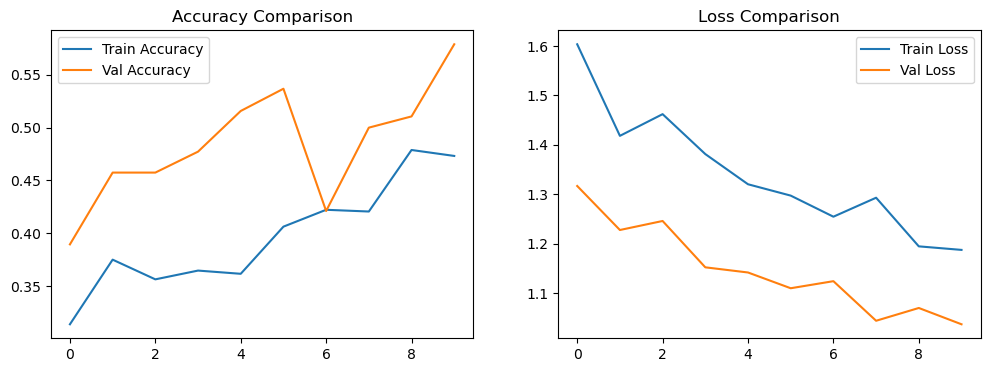

In [41]:
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

# 1. SPLIT DATA
# Split your niche dataset using the local paths from the download step
train_df, val_df = train_test_split(niche_df, test_size=0.2, stratify=niche_df['Body'])

label_map = {name: i for i, name in enumerate(selected_classes)}
train_paths = train_df['local_path'].values
train_labels = train_df['Body'].map(label_map).values
val_paths = val_df['local_path'].values
val_labels = val_df['Body'].map(label_map).values

# 2. ROBUST DATA GENERATOR
# This skips corrupt files and standardizes image dimensions [cite: 9]
def image_generator(paths, labels, batch_size=32):
    while True:
        # Shuffle indices at the start of each epoch
        indices = np.arange(len(paths))
        np.random.shuffle(indices)
        
        for i in range(0, len(paths), batch_size):
            batch_idx = indices[i:i+batch_size]
            images = []
            targets = []
            
            for idx in batch_idx:
                try:
                    # PIL is more robust than tf.io for diverse web formats
                    img = Image.open(paths[idx]).convert('RGB')
                    img = img.resize((224, 224))
                    img_array = np.array(img) / 255.0
                    
                    if img_array.shape == (224, 224, 3):
                        images.append(img_array)
                        targets.append(labels[idx])
                except:
                    continue # Silently skip corrupt or missing files
            
            if len(images) > 0:
                yield np.array(images), np.array(targets)

# Initialize Generators
train_gen = image_generator(train_paths, train_labels)
val_gen = image_generator(val_paths, val_labels)

# Calculate actual steps (crucial for .fit)
steps_per_epoch = len(train_paths) // 32
val_steps = len(val_paths) // 32

# 3. DEFINE TRANSFER LEARNING MODEL
# Requirements: MobileNetV2 [cite: 22], Frozen Backbone [cite: 30], GAP Head [cite: 27]
def build_transfer_model(num_classes):
    # Load pre-trained MobileNetV2 backbone [cite: 22]
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3), include_top=False, weights='imagenet'
    )
    
    # Freeze the entire backbone [cite: 30, 31]
    base_model.trainable = False 
    
    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        
        # Methodology Req: Data Augmentation [cite: 9, 19]
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.2),
        layers.RandomContrast(0.2),
        
        base_model,
        
        # Methodology Req: GAP instead of Flatten 
        layers.GlobalAveragePooling2D(), 
        
        layers.Dropout(0.3), # Mitigate overfitting [cite: 9, 29]
        layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# 4. EXECUTE TRAINING [cite: 35]
transfer_model = build_transfer_model(len(selected_classes))

print("Starting Training (MobileNetV2 Transfer Learning)...")
history = transfer_model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=val_steps,
    epochs=10
)

# 5. PLOT PERFORMANCE CURVES 
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Comparison')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Comparison')
plt.legend()

plt.show()

In [43]:
# Run this to see where the model is confused
import numpy as np

# Get a batch from the validation generator
images, labels = next(val_gen)
preds = transfer_model.predict(images)

for i in range(len(preds)):
    pred_label = np.argmax(preds[i])
    true_label = labels[i]
    if pred_label != true_label:
        print(f"Image {i}: Predicted {selected_classes[pred_label]}, Actual {selected_classes[true_label]}")
        # Use plt.imshow(images[i]) to see the specific image

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 970ms/step
Image 1: Predicted Coupe, Actual Convertible
Image 4: Predicted Compact, Actual Sedan
Image 5: Predicted Coupe, Actual Convertible
Image 6: Predicted Sedan, Actual Compact
Image 8: Predicted Convertible, Actual Sedan
Image 9: Predicted Convertible, Actual Coupe
Image 11: Predicted Compact, Actual Coupe
Image 12: Predicted Compact, Actual Convertible
Image 14: Predicted Sedan, Actual Compact
Image 18: Predicted Coupe, Actual Compact
Image 19: Predicted Coupe, Actual Sedan
Image 20: Predicted Compact, Actual Sedan
Image 21: Predicted Coupe, Actual Convertible
Image 25: Predicted Compact, Actual Sedan
Image 27: Predicted Coupe, Actual Convertible
Image 28: Predicted Sedan, Actual Compact


In [44]:
# Requirement: Build a simple CNN from scratch [cite: 16]
def build_baseline_model(num_classes):
    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        # Apply the same augmentation used in transfer learning [cite: 20]
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.2),
        layers.RandomContrast(0.2),
        
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.GlobalAveragePooling2D(), 
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Train the baseline
baseline_model = build_baseline_model(len(selected_classes))
print("Training Baseline from Scratch...")
h_baseline = baseline_model.fit(train_gen, steps_per_epoch=steps_per_epoch, 
                                 validation_data=val_gen, validation_steps=val_steps, epochs=10)

Training Baseline from Scratch...
Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.3013 - loss: 1.6121 - val_accuracy: 0.3371 - val_loss: 1.3966
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.3348 - loss: 1.3819 - val_accuracy: 0.3229 - val_loss: 1.3523
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.3192 - loss: 1.3874 - val_accuracy: 0.2737 - val_loss: 1.3500
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.3348 - loss: 1.3526 - val_accuracy: 0.3438 - val_loss: 1.3436
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.3118 - loss: 1.3779 - val_accuracy: 0.2955 - val_loss: 1.3320
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.3535 - loss: 1.3482 - val_accuracy: 0.3125 - val_loss: 1.3469
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.2984 - loss: 1.3586 - val_accuracy: 0.3229 - val_loss: 1.3530
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.3445 - loss: 1.3558 

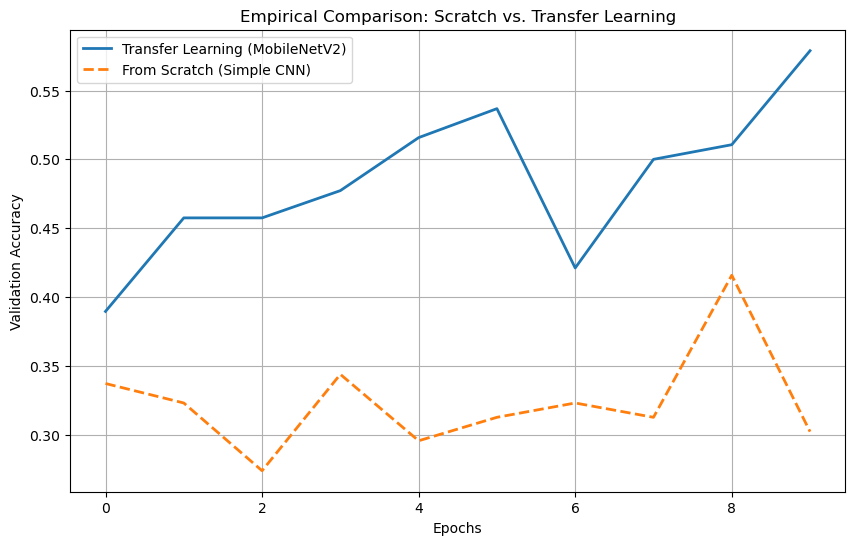

In [46]:
plt.figure(figsize=(10, 6))

# Plot Transfer Learning Accuracy (Already completed in your previous step)
plt.plot(history.history['val_accuracy'], label='Transfer Learning (MobileNetV2)', linewidth=2)

# Plot Baseline Accuracy
plt.plot(h_baseline.history['val_accuracy'], label='From Scratch (Simple CNN)', linestyle='--', linewidth=2)

plt.title('Empirical Comparison: Scratch vs. Transfer Learning')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()